In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Import necessary libraries and the data set
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Save the DataFrame to a CSV file in the current directory of your Colab environment
df = pd.read_csv("/content/drive/MyDrive/PCOS_data_without_infertility.csv")
df


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1.0,1.0,0.0,28.0,44.6,152.0,19.3,15.0,78.0,22.0,...,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5,NaN
1,2.0,2.0,0.0,36.0,65.0,161.5,#NAME?,15.0,74.0,20.0,...,0.0,0.0,120.0,70.0,3.0,5.0,15.0,14.0,3.7,NaN
2,3.0,3.0,1.0,33.0,68.8,165.0,#NAME?,11.0,72.0,18.0,...,1.0,0.0,120.0,80.0,13.0,15.0,18.0,20.0,10.0,NaN
3,4.0,4.0,0.0,37.0,65.0,148.0,#NAME?,13.0,72.0,20.0,...,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5,NaN
4,5.0,5.0,0.0,25.0,52.0,161.0,#NAME?,11.0,72.0,18.0,...,0.0,0.0,120.0,80.0,3.0,4.0,16.0,14.0,7.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#basic info
df.info()
df.describe()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    float64
 1   Patient File No.        541 non-null    float64
 2   PCOS (Y/N)              541 non-null    float64
 3    Age (yrs)              541 non-null    float64
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    object 
 7   Blood Group             541 non-null    float64
 8   Pulse rate(bpm)         541 non-null    float64
 9   RR (breaths/min)        541 non-null    float64
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    float64
 12  Cycle length(days)      541 non-null    float64
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    fl

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')

**Data Cleaning**

In [ ]:
#drop rows that are blank that got transfered over csv
df = df.dropna(subset=['Patient File No.'])

#drop unnamed colums
unnamed_cols = [col for col in df.columns if 'Unnamed:' in col]
df = df.drop(columns=unnamed_cols)

#drop redundant columns (index, patient file no, and Sl number were all the same)
df = df.drop(['Patient File No.', 'Sl. No'], axis=1)

#drop unnecessary columns
df = df.drop(['Marraige Status (Yrs)', 'No. of aborptions'], axis=1)

In [ ]:
#relabel columns for continuity and simplicity (camelCase_label)
df.columns = ['PCOS', 'age', 'weight_kg',
       'height_cm', 'BMI', 'bloodType', 'pulse_bpm',
       'respitoryRate_bpm', 'hemoglobin_g/dl', 'regularCycle', 'cycleLength',
       'pregnant','Case1Beta-HCG_mIU/mL', 'Case2Beta-HCG_mIU/mL', 'follicleStimulatingHormone_mIU/mL',
       'LutenizingHormone_mIU/mL', 'FSH/LH', 'hip_in', 'waist_in', 'waistHipRatio',
       'thyroidStimulatingHormone_mIU/L', 'antiMüllerianHormone_ng/mL', 'prolactin_ng/mL', 'vitaminD3_ng/mL',
       'progesterone_ng/mL', 'randomBloodSugar_mg/dl', 'weightGain', 'hairGrowth',
       'skinDarkening', 'hairLoss', 'pimples',
       'fastFood', 'regularExercise', 'bpSystolic_mmHg',
       'bpDiastolic_mmHg', 'follicleCountLeft', 'follicleCountRight',
       'avgFollicleSizeLeft_mm', 'avgFollicleSizeRight_mm', 'endometrium_mm']

In [ ]:
#fix cells that were inputted wrong
df.loc[123, 'Case2Beta-HCG_mIU/mL'] = 1.99

df = df.drop(index=305)

df.loc[455, 'LutenizingHormone_mIU/mL'] = 2.018
df.loc[329, 'follicleStimulatingHormone_mIU/mL'] = 5.052


In [ ]:
#map values onto Y/N questions and columns that have numbering system for values
#for col in ['PCOS', 'pregnant', 'weightGain', 'hairGrowth', 'skinDarkening', 'hairLoss', 'pimples','fastFood', 'regularExercise']:
#  df[col] = df[col].map({1:True, 0:False})

#df['bloodType'] = df['bloodType'].map({11:'A+', 12:'A-', 13:'B+', 14:'B-', 15:'O+', 16:'O-', 17:'AB+', 18:'AB-'})
#df['regularCycle'] = df['regularCycle'].map({4:False, 2:True})

#round off values that only need one decimal place
df['BMI'] = (df['weight_kg']/(df['height_cm']/100)**2).round(1)
df['height_cm'] = df['height_cm'].round(1)
df['FSH/LH'] = df['follicleStimulatingHormone_mIU/mL']/df['LutenizingHormone_mIU/mL']
df['waistHipRatio'] = df['waist_in']/df['hip_in']

df.info()

for col in df:
  df[col] = df[col].astype(str).astype(float)



<class 'pandas.core.frame.DataFrame'>
Index: 540 entries, 0 to 540
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   PCOS                               540 non-null    float64
 1   age                                540 non-null    float64
 2   weight_kg                          540 non-null    float64
 3   height_cm                          540 non-null    float64
 4   BMI                                540 non-null    float64
 5   bloodType                          540 non-null    float64
 6   pulse_bpm                          540 non-null    float64
 7   respitoryRate_bpm                  540 non-null    float64
 8   hemoglobin_g/dl                    540 non-null    float64
 9   regularCycle                       540 non-null    float64
 10  cycleLength                        540 non-null    float64
 11  pregnant                           540 non-null    float64
 12 

In [ ]:
#set up new dataframes based on important factors
pregnant = df[df['pregnant']==1.0]
notPregnant = df[df['pregnant']==0.0]

In [ ]:
notPregnant

,PCOS,age,weight_kg,height_cm,BMI,bloodType,pulse_bpm,respitoryRate_bpm,hemoglobin_g/dl,regularCycle,...,pimples,fastFood,regularExercise,bpSystolic_mmHg,bpDiastolic_mmHg,follicleCountLeft,follicleCountRight,avgFollicleSizeLeft_mm,avgFollicleSizeRight_mm,endometrium_mm
0,0.0,28.0,44.6,152.0,19.3,15.0,78.0,22.0,10.48,2.0,...,0.0,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
3,0.0,37.0,65.0,148.0,29.7,13.0,72.0,20.0,12.00,2.0,...,0.0,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
6,0.0,34.0,64.0,156.0,26.3,11.0,72.0,18.0,10.90,2.0,...,0.0,0.0,0.0,120.0,80.0,6.0,6.0,15.0,16.0,6.8
8,0.0,32.0,40.0,158.0,16.0,11.0,72.0,18.0,11.80,2.0,...,0.0,0.0,0.0,120.0,80.0,5.0,7.0,17.0,17.0,4.2
9,0.0,36.0,52.0,150.0,23.1,15.0,80.0,20.0,10.00,4.0,...,0.0,0.0,0.0,110.0,80.0,1.0,1.0,14.0,17.0,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,0.0,26.0,80.0,161.5,30.7,18.0,70.0,18.0,10.60,2.0,...,0.0,0.0,0.0,110.0,80.0,7.0,9.0,13.0,17.5,9.6
536,0.0,35.0,50.0,164.6,18.5,17.0,72.0,16.0,11.00,2.0,...,0.0,0.0,0.0,110.0,70.0,1.0,0.0,17.5,10.0,6.7
538,0.0,36.0,54.0,152.0,23.4,13.0,74.0,20.0,10.80,2.0,...,0.0,0.0,0.0,110.0,80.0,1.0,0.0,18.0,9.0,7.3
539,0.0,27.0,50.0,150.0,22.2,15.0,74.0,20.0,12.00,4.0,...,1.0,0.0,0.0,110.0,70.0,7.0,6.0,18.0,16.0,11.5


In [ ]:
#set up focus_features
reproductive_features = ['PCOS', 'regularCycle', 'cycleLength', 'Case1Beta-HCG_mIU/mL',
                         'Case2Beta-HCG_mIU/mL', 'follicleStimulatingHormone_mIU/mL',
                         'LutenizingHormone_mIU/mL', 'FSH/LH', 'thyroidStimulatingHormone_mIU/L',
                         'antiMüllerianHormone_ng/mL', 'prolactin_ng/mL', 'progesterone_ng/mL',
                         'follicleCountLeft', 'follicleCountRight', 'avgFollicleSizeLeft_mm',
                         'avgFollicleSizeRight_mm', 'endometrium_mm']

typical_PCOS_features = ['weightGain', 'hairGrowth',
                        'skinDarkening', 'hairLoss', 'pimples']

comp_health_features = ['PCOS', 'age', 'weight_kg','height_cm', 'BMI', 'bloodType',
                        'pulse_bpm', 'respitoryRate_bpm', 'hemoglobin_g/dl',
                        'hip_in', 'waist_in', 'waistHipRatio', 'vitaminD3_ng/mL',
                        'randomBloodSugar_mg/dl', 'fastFood', 'regularExercise',
                        'bpSystolic_mmHg', 'bpDiastolic_mmHg',]
hormone_features = ['PCOS', 'Case1Beta-HCG_mIU/mL',
                         'Case2Beta-HCG_mIU/mL', 'follicleStimulatingHormone_mIU/mL',
                         'LutenizingHormone_mIU/mL', 'FSH/LH', 'thyroidStimulatingHormone_mIU/L',
                         'antiMüllerianHormone_ng/mL', 'prolactin_ng/mL', 'progesterone_ng/mL',
                         'follicleCountLeft']

num_features = ['age', 'weight_kg',
       'height_cm', 'BMI', 'bloodType', 'pulse_bpm',
       'respitoryRate_bpm', 'hemoglobin_g/dl', 'cycleLength',
       'Case1Beta-HCG_mIU/mL', 'Case2Beta-HCG_mIU/mL', 'follicleStimulatingHormone_mIU/mL',
       'LutenizingHormone_mIU/mL', 'FSH/LH', 'hip_in', 'waist_in', 'waistHipRatio',
       'thyroidStimulatingHormone_mIU/L', 'antiMüllerianHormone_ng/mL', 'prolactin_ng/mL', 'vitaminD3_ng/mL',
       'progesterone_ng/mL', 'randomBloodSugar_mg/dl', 'bpSystolic_mmHg',
       'bpDiastolic_mmHg', 'follicleCountLeft', 'follicleCountRight',
       'avgFollicleSizeLeft_mm', 'avgFollicleSizeRight_mm', 'endometrium_mm']

**Model Data**

<Axes: >

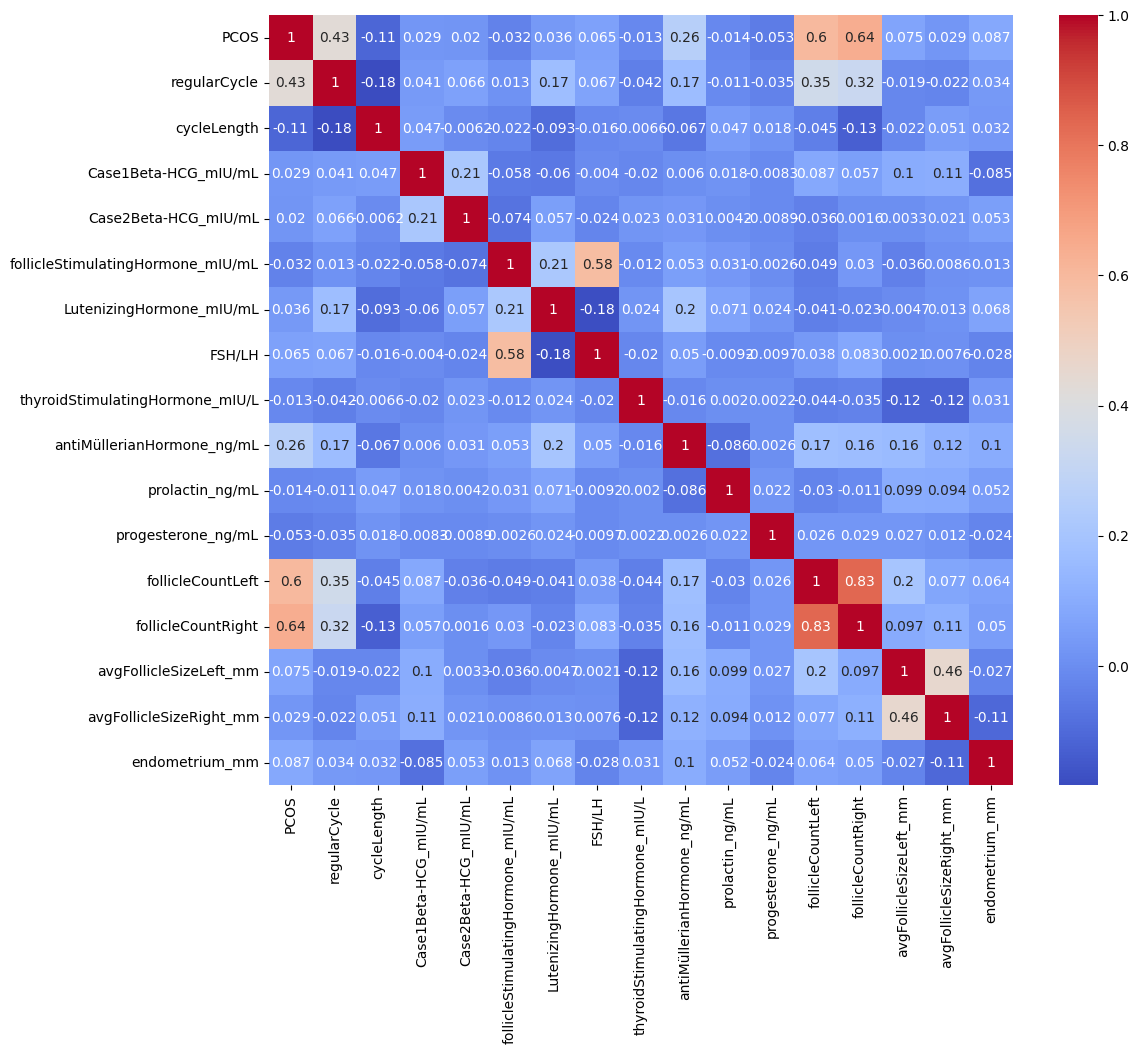

In [ ]:
correlation_map3 = notPregnant[reproductive_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))


sns.heatmap(data=correlation_map3, cmap='coolwarm', annot=True, ax=ax)

<Axes: >

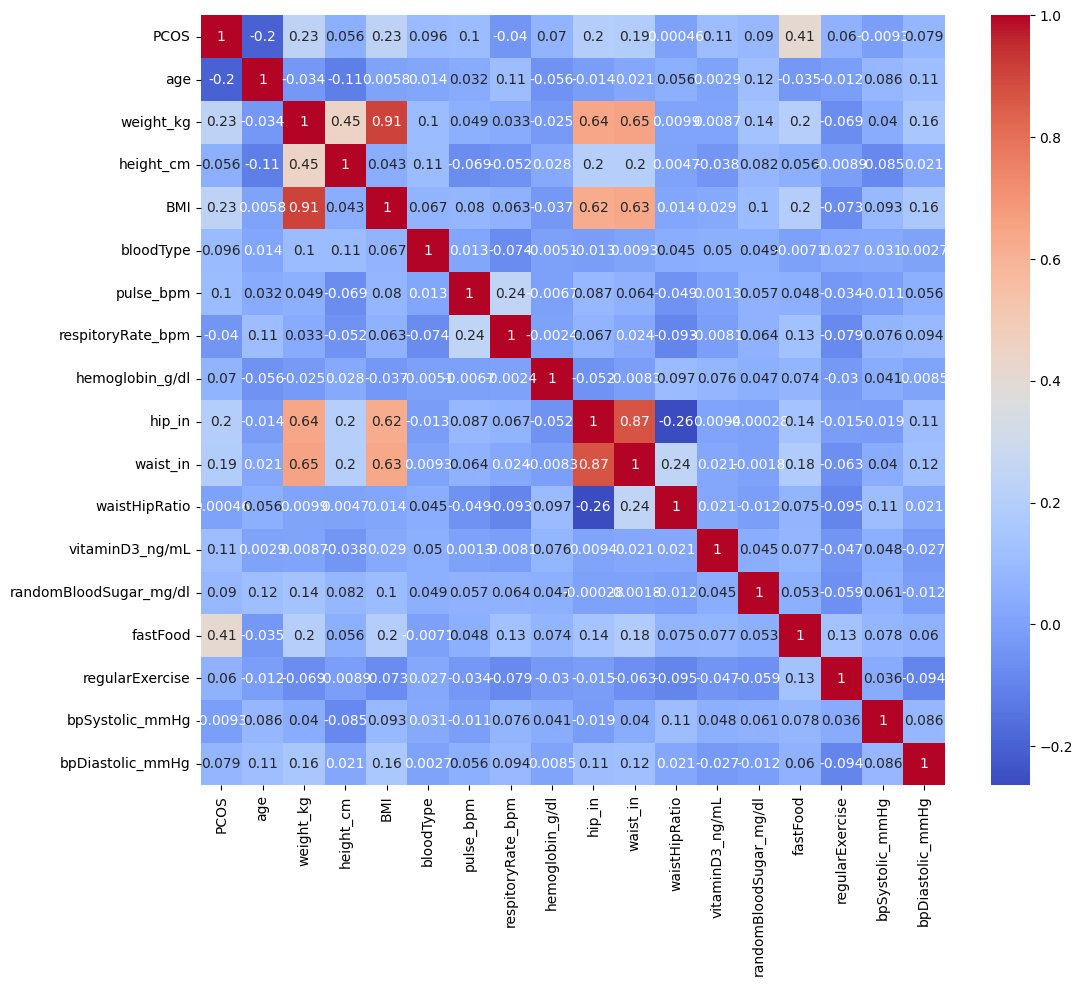

In [ ]:
correlation_map4 = notPregnant[comp_health_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(data=correlation_map4, cmap='coolwarm', annot=True, ax=ax)

<Axes: >

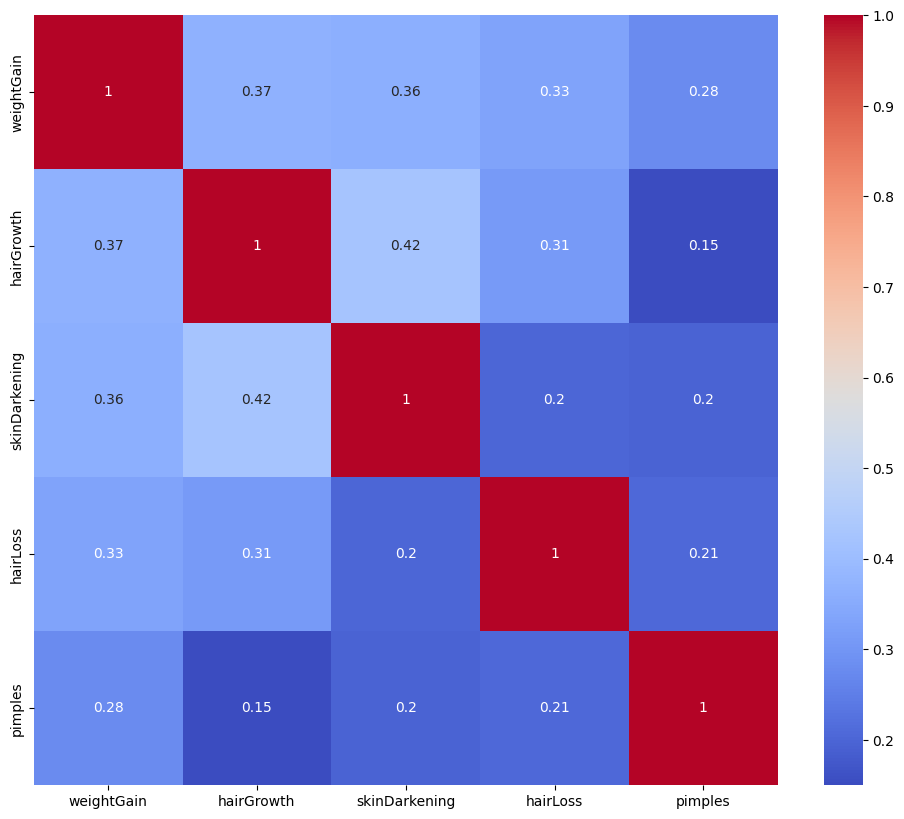

In [ ]:
correlation_map4 = notPregnant[typical_PCOS_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(data=correlation_map4, cmap='coolwarm', annot=True, ax=ax)

<Axes: xlabel='follicleCountLeft', ylabel='follicleCountRight'>

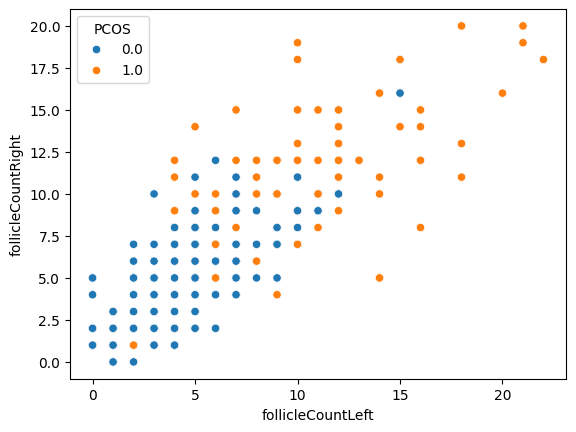

In [ ]:
sns.scatterplot(data=notPregnant, x='follicleCountLeft', y='follicleCountRight', hue='PCOS')

<Axes: xlabel='follicleStimulatingHormone_mIU/mL', ylabel='LutenizingHormone_mIU/mL'>

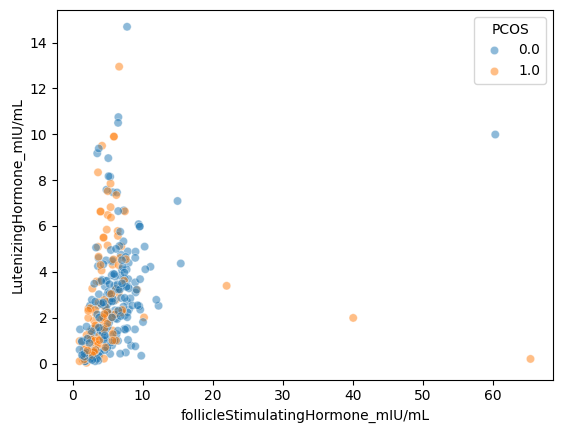

In [ ]:
sns.scatterplot(data=notPregnant, x='follicleStimulatingHormone_mIU/mL', y='LutenizingHormone_mIU/mL', hue='PCOS', alpha=.5)

<Axes: xlabel='antiMüllerianHormone_ng/mL', ylabel='Count'>

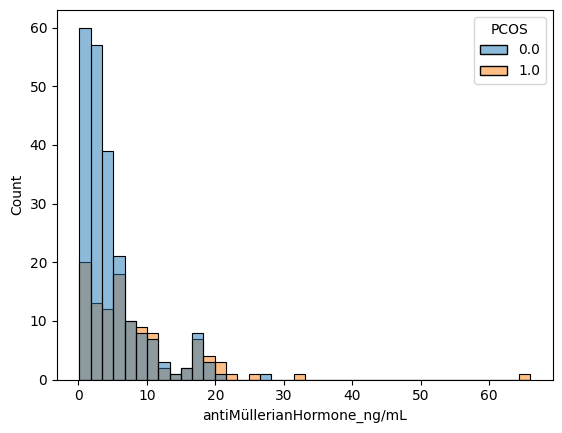

In [ ]:
sns.histplot(data=notPregnant, x='antiMüllerianHormone_ng/mL', hue='PCOS')

<Axes: xlabel='thyroidStimulatingHormone_mIU/L', ylabel='prolactin_ng/mL'>

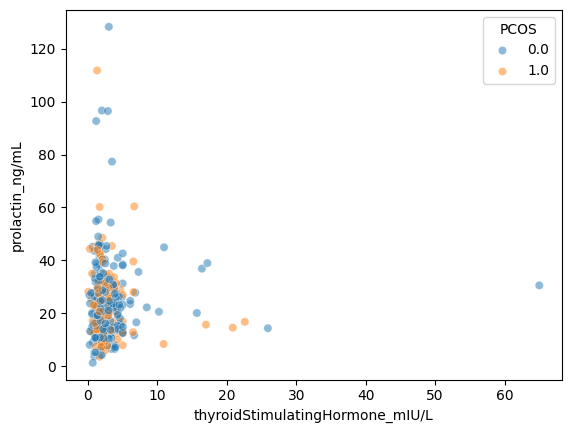

In [ ]:
sns.scatterplot(data=notPregnant, x='thyroidStimulatingHormone_mIU/L', y='prolactin_ng/mL', hue='PCOS', alpha=0.5)

<Axes: xlabel='LutenizingHormone_mIU/mL', ylabel='prolactin_ng/mL'>

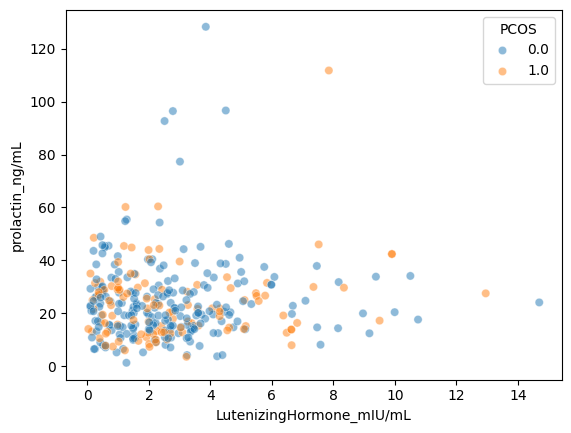

In [ ]:
sns.scatterplot(data=notPregnant, x='LutenizingHormone_mIU/mL', y='prolactin_ng/mL', hue='PCOS', alpha=0.5)

<Axes: xlabel='thyroidStimulatingHormone_mIU/L', ylabel='follicleStimulatingHormone_mIU/mL'>

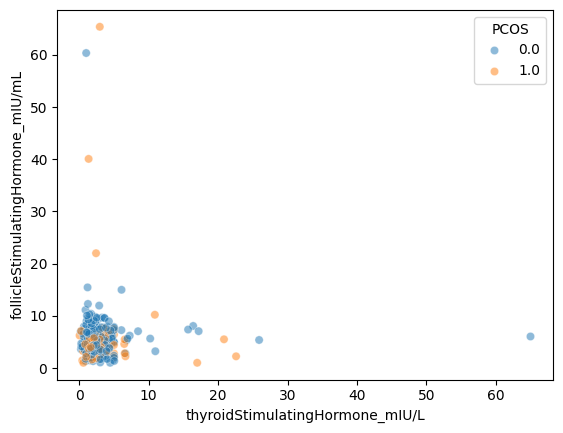

In [ ]:
sns.scatterplot(data=notPregnant, x='thyroidStimulatingHormone_mIU/L', y='follicleStimulatingHormone_mIU/mL', hue='PCOS', alpha=0.5)

<Axes: xlabel='antiMüllerianHormone_ng/mL', ylabel='follicleCountRight'>

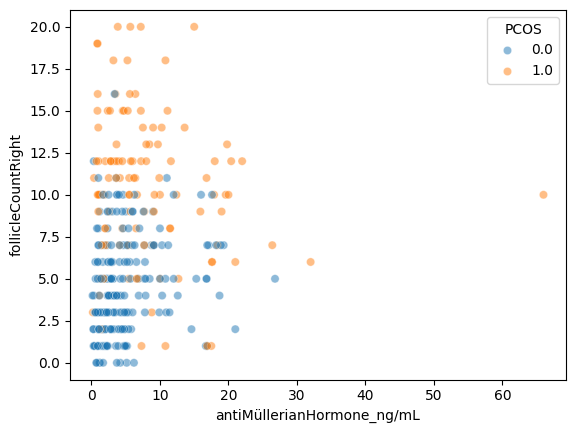

In [ ]:
sns.scatterplot(data=notPregnant, x='antiMüllerianHormone_ng/mL', y='follicleCountRight', hue='PCOS', alpha=0.5)

<Axes: xlabel='follicleCountRight', ylabel='follicleStimulatingHormone_mIU/mL'>

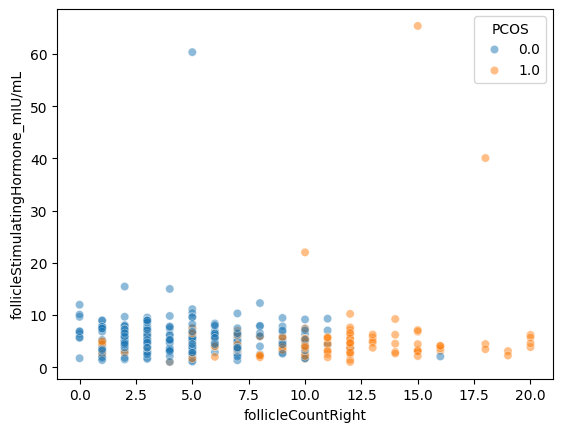

In [ ]:
sns.scatterplot(data=notPregnant, x='follicleCountRight', y='follicleStimulatingHormone_mIU/mL', hue='PCOS', alpha=0.5)

<Axes: xlabel='PCOS', ylabel='follicleCountRight'>

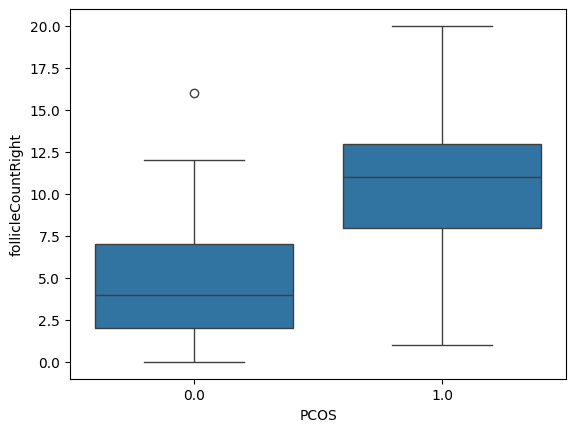

In [ ]:
sns.boxplot(x="PCOS", y="follicleCountRight", data=notPregnant)

<Axes: xlabel='PCOS', ylabel='LutenizingHormone_mIU/mL'>

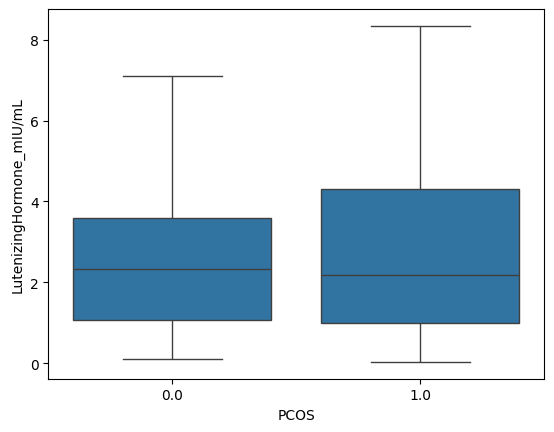

In [ ]:
sns.boxplot(x="PCOS", y="LutenizingHormone_mIU/mL", data=notPregnant, showfliers=False)

<Axes: xlabel='PCOS', ylabel='FSH/LH'>

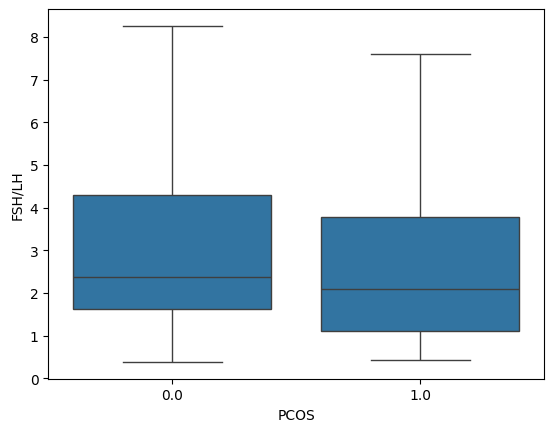

In [ ]:
sns.boxplot(x="PCOS", y="FSH/LH", data=notPregnant, showfliers=False)

<Axes: xlabel='cycleLength', ylabel='Count'>

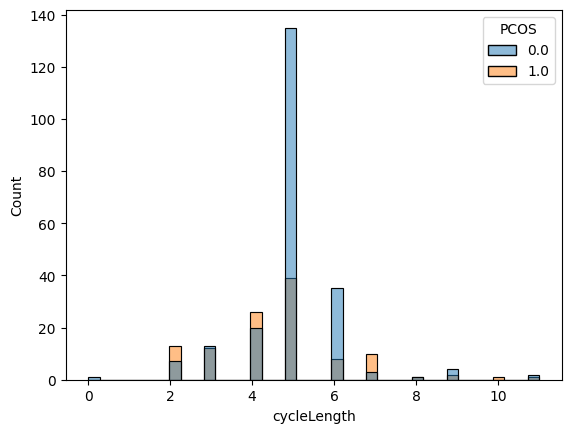

In [ ]:
sns.histplot(data=notPregnant, x='cycleLength', hue='PCOS')

<Axes: xlabel='endometrium_mm', ylabel='Count'>

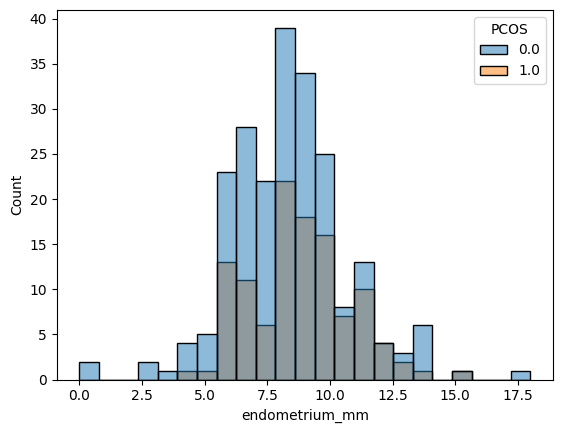

In [ ]:
sns.histplot(data=notPregnant, x='endometrium_mm', hue='PCOS')

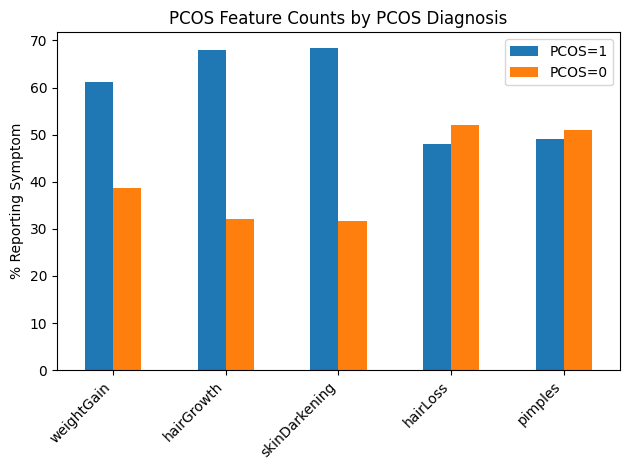

In [ ]:
counts = pd.DataFrame({
    "PCOS=1": (notPregnant[notPregnant["PCOS"] == 1][typical_PCOS_features].sum()/notPregnant[typical_PCOS_features].sum())*100,
    "PCOS=0": (notPregnant[notPregnant["PCOS"] == 0][typical_PCOS_features].sum()/notPregnant[typical_PCOS_features].sum())*100
})

# Plot
counts.plot(kind="bar")
plt.ylabel("% Reporting Symptom")
plt.title("PCOS Feature Counts by PCOS Diagnosis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**ML Models**

In [ ]:
#set up focus features based on graphs
focus_features = ['weightGain', 'hairGrowth',
       'skinDarkening','follicleCountLeft', 'follicleCountRight']

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
notPregnant[focus_features] = scaler.fit_transform(notPregnant[focus_features])

X = notPregnant[focus_features]
y = notPregnant['PCOS']

/tmp/ipython-input-2891058719.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  notPregnant[focus_features] = scaler.fit_transform(notPregnant[focus_features])


In [ ]:
#ML Model 1
dt = DecisionTreeClassifier(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
dt.fit(X_train,y_train)
y_prediction = dt.predict(X_test)
print(accuracy_score(y_test, y_prediction))


0.835820895522388


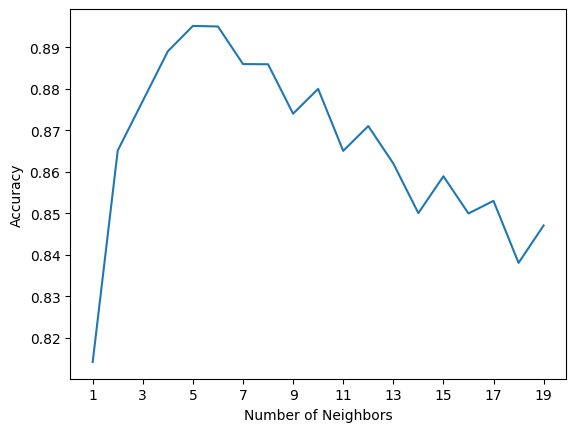

In [ ]:
#ML Model 2

xvals = []
yvals = []
fig, ax = plt.subplots()

#Gridsearch to find optimum K value
for i in range(1,20):
  knn = KNeighborsClassifier(n_neighbors = i)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  knn.fit(X_train,y_train)
  y_prediction = knn.predict(X_test)
  acc = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
  xvals.append(i)
  yvals.append(acc.mean())
plt.plot(xvals, yvals)
ax.set_xticks(np.arange(1, 20, 2))
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
best_model = KNeighborsClassifier(n_neighbors = 6)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

0.8949796472184532
AUC: 0.9199604743083005


/tmp/ipython-input-2701431960.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


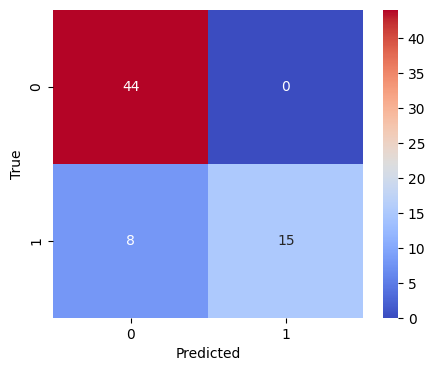

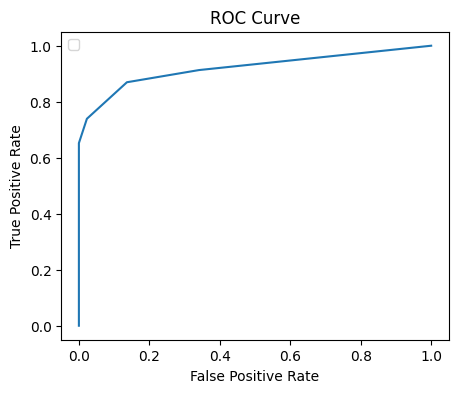

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

#predictions with probablity
y_prob = best_model.predict_proba(X_test)[:,1]

#classification accuracy
print(cross_val_score(best_model, X, y, cv=5, scoring='accuracy').mean())

#confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

#confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('True')

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

#AUC
print('AUC: '+str(roc_auc))

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In [ ]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92        44
         1.0       1.00      0.65      0.79        23

    accuracy                           0.88        67
   macro avg       0.92      0.83      0.85        67
weighted avg       0.90      0.88      0.87        67



**Feature Engineering**

In [ ]:
newDf = pd.DataFrame()
knn2 = KNeighborsClassifier(n_neighbors=11)

#add one column at a time and compare model performance
for i in focus_features:
    newDf[i] = df[i]
    X = newDf
    y = df['PCOS']
    acc = cross_val_score(knn2, X, y, cv=5, scoring='accuracy')
    print(i, acc.mean())

weightGain 0.6962962962962963
hairGrowth 0.7537037037037037
skinDarkening 0.8
follicleCountLeft 0.8444444444444443
follicleCountRight 0.861111111111111


**Feature Engineering**

In [ ]:
#create new column from 2 columns
newDf['totalFollicleCount'] = df['follicleCountLeft'] + df['follicleCountRight']
newDf = newDf.drop('follicleCountLeft', axis=1)
newDf = newDf.drop('follicleCountRight', axis=1)


In [ ]:
X = newDf
y = df['PCOS']
acc = cross_val_score(knn2, X, y, cv=5, scoring='accuracy')
print(acc.mean())

0.8685185185185185


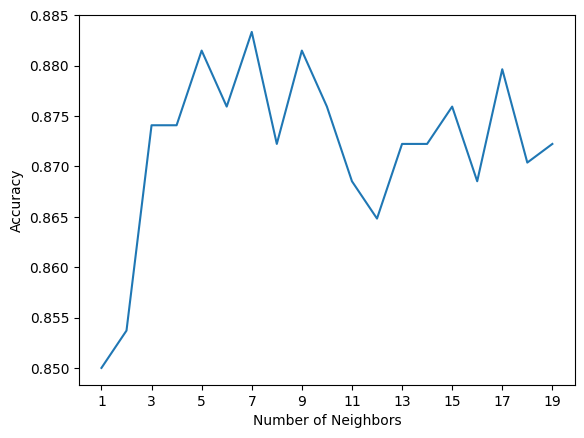

0.875925925925926
AUC: 0.9311111111111111


/tmp/ipython-input-3009318681.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


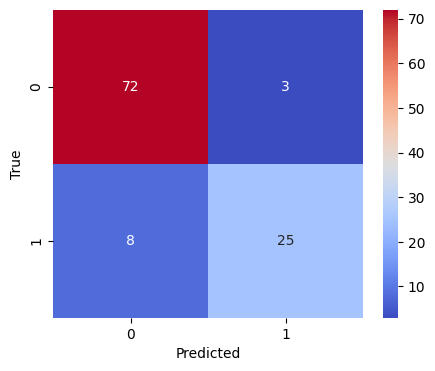

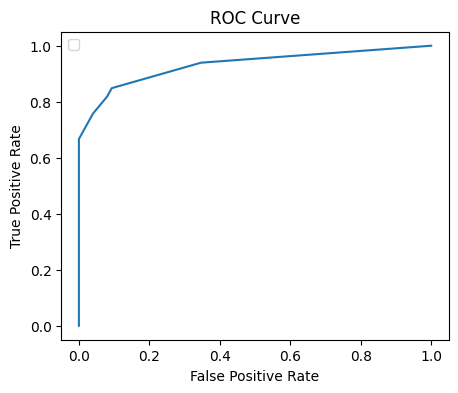

In [ ]:
xvals = []
yvals = []
fig, ax = plt.subplots()

#Gridsearch to find optimum K value
for i in range(1,20):
  knn = KNeighborsClassifier(n_neighbors = i)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  knn.fit(X_train,y_train)
  y_prediction = knn.predict(X_test)
  acc = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
  xvals.append(i)
  yvals.append(acc.mean())
plt.plot(xvals, yvals)
ax.set_xticks(np.arange(1, 20, 2))
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()

best_model = KNeighborsClassifier(n_neighbors = 6)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

#predictions with probablity
y_prob = best_model.predict_proba(X_test)[:,1]

#classification accuracy
print(cross_val_score(best_model, X, y, cv=5, scoring='accuracy').mean())

#confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

#confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('True')

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

#AUC
print('AUC: '+str(roc_auc))

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Testing Hypothesis**

In [ ]:
newDf = newDf.drop('totalFollicleCount', axis=1)

In [ ]:
X = newDf
y = df['PCOS']
acc = cross_val_score(knn2, X, y, cv=5, scoring='accuracy')
print(acc.mean())

0.8
